In [5]:
import pandas as pd #  pandas
import seaborn as sns # seaborn
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import numpy as np
import seaborn as snst
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

# Exploración inicial tareas

Se crea la función analizar para dividir los dataset según el número de tarea de manera que incluye las variables correspodientes solo a dicha tarea y la variable *'class'* con los pacientes (P) y sanos (H).

Divido el dataset, se realiza una serie de análisis descriptivos, heatmap y boxplot para el conjunto de datos, según la tarea.

✅ Analizando Tarea 23 (18 variables)

Primeras filas del conjunto de datos:
   air_time23  disp_index23  gmrt_in_air23  gmrt_on_paper23  \
0       10965      0.000009     126.658709       190.158460   
1       14660      0.000011      85.909291        52.977313   
2        7330      0.000011     117.765304       189.682156   
3        7205      0.000010     211.397750       166.255725   
4        5340      0.000008     104.338067       157.823013   

   max_x_extension23  max_y_extension23  mean_acc_in_air23  \
0                788               5828           0.180354   
1                848               5800           0.289629   
2               1338               8208           0.229316   
3               1429               6663           0.236979   
4                761               5183           0.192639   

   mean_acc_on_paper23  mean_gmrt23  mean_jerk_in_air23  mean_jerk_on_paper23  \
0             0.148444   158.408585            0.024301              0.020756   
1         

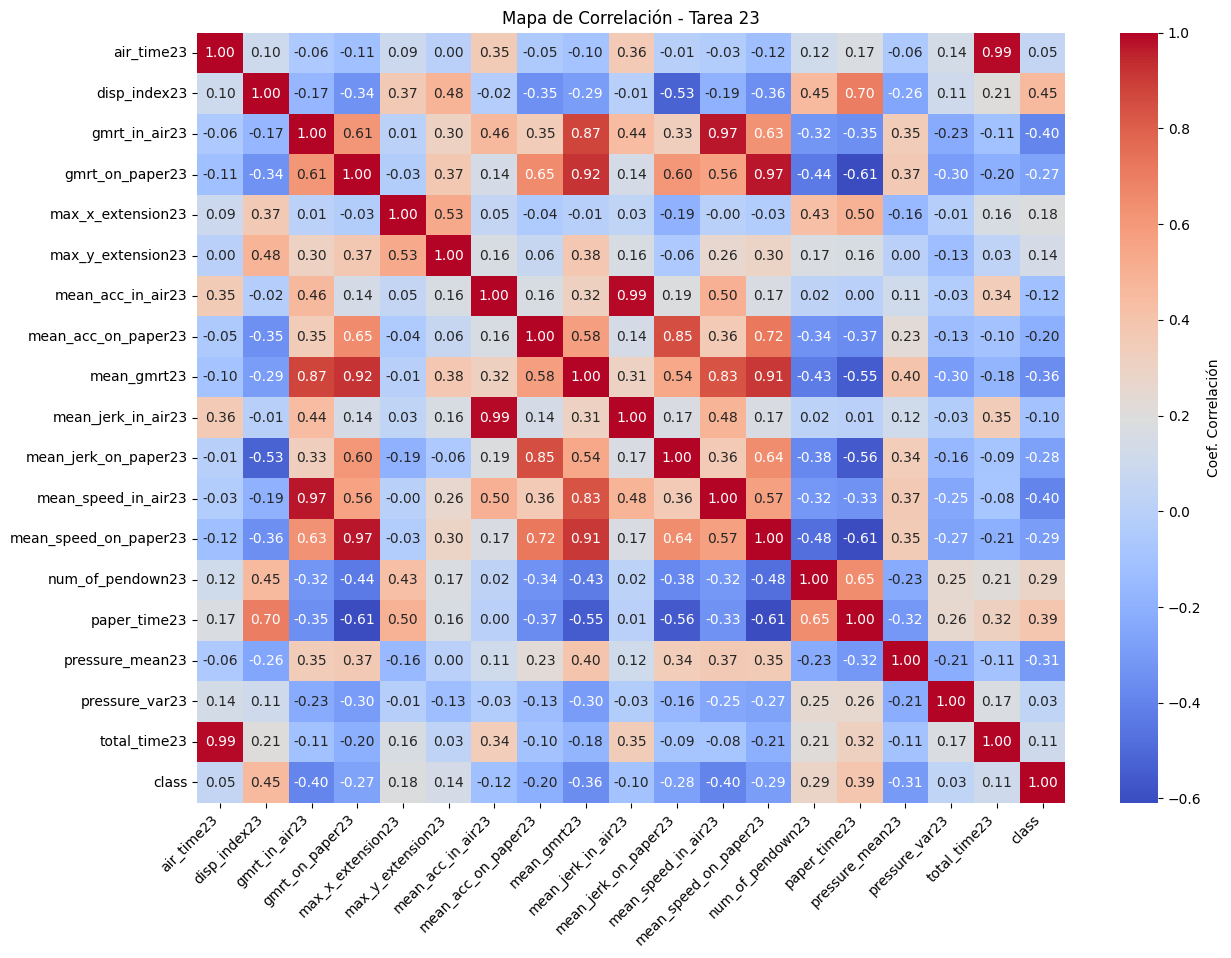

/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_18563/74461179.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=var, data=df_tarea, ax=axes[i], palette='Set2')
/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_18563/74461179.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=var, data=df_tarea, ax=axes[i], palette='Set2')
/var/folders/d1/t7mn_x7d347_ghm2vrnvdsk40000gn/T/ipykernel_18563/74461179.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=var, data=df_tarea, ax=axes[i],

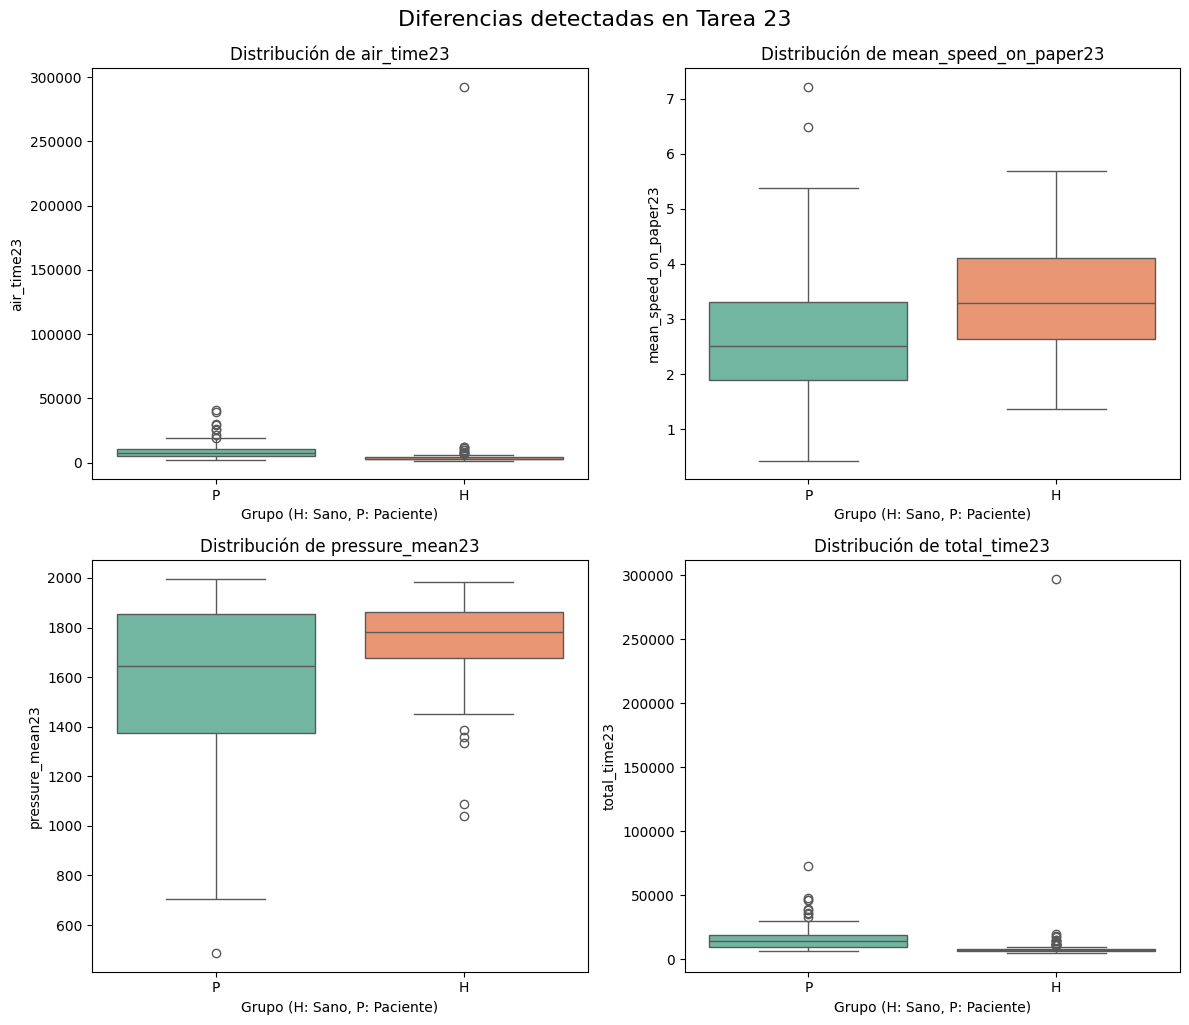

In [6]:
def analizar_tarea(df, num_tarea):
    """
    Analiza una tarea específica (1-25) filtrando columnas con precisión.
    """
    suffix = str(num_tarea)
    
    # --- FILTRADO CORRECTO ---
    # Buscamos columnas que terminen en el número de tarea, 
    # pero asegurándonos de que el carácter anterior NO sea otro dígito.
    # Ejemplo: para num_tarea=1, 'air_time1' coincide, pero 'air_time11' NO.
    cols_tarea = []
    for col in df.columns:
        if col.endswith(suffix):
            # Verificamos el prefijo del número para no confundir 1 con 11, 21...
            posible_prefijo = col[:-(len(suffix))]
            if not posible_prefijo[-1:].isdigit():
                cols_tarea.append(col)

    if not cols_tarea:
        print(f"⚠️ No se encontraron columnas para la tarea {num_tarea}")
        return

    print(f"✅ Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Crear un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()

    # -- Análisis descriptivo inicial --
    filas = df_tarea.shape[0] # núm filas
    columnas = df_tarea.shape[1] # núm columnas
    print("\nPrimeras filas del conjunto de datos:")
    print(df_tarea.head())

    print("\nEstadística descriptiva inicial:")
    print(f"El conjunto de datos tiene {filas} filas y {columnas} columnas") # dimensiones

    print("\nLos nombre de las columnas son:")
    print(df_tarea.columns)

    print("\nEstadística descriptiva de las variables:")
    print(df_tarea.describe())

    print("\Media de valores para pacinetes (P) vs sanos (H) en lsa variables:")
    print(df_tarea.groupby('class').mean(numeric_only=True))
    
    
    # --- Heatmap de Correlaciones ---
    plt.figure(figsize=(14, 10))
    df_corr = df_tarea.copy()
    # Convertimos la clase a numérico para la correlación: P (Paciente/Alzheimer) = 1, H (Sano) = 0
    df_corr['class'] = df_corr['class'].map({'P': 1, 'H': 0})
    
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Coef. Correlación'})
    plt.title(f'Mapa de Correlación - Tarea {num_tarea}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

    # --- Boxplots de variables clave ---
    # Definimos las métricas base que queremos ver
    metrics = ['air_time', 'pressure_mean', 'mean_speed_on_paper', 'total_time']
    # Buscamos los nombres reales en las columnas filtradas (ya que a veces varían ligeramente)
    variables_interes = [c for c in cols_tarea if any(m in c for m in metrics)]
    
    # Limitamos a 4 para el gráfico 2x2
    variables_interes = variables_interes[:4]
    
    if variables_interes:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        
        for i, var in enumerate(variables_interes):
            sns.boxplot(x='class', y=var, data=df_tarea, ax=axes[i], palette='Set2')
            axes[i].set_title(f'Distribución de {var}')
            axes[i].set_xlabel('Grupo (H: Sano, P: Paciente)')
        
        plt.tight_layout()
        plt.suptitle(f'Diferencias detectadas en Tarea {num_tarea}', fontsize=16, y=1.02)
        plt.show()
    else:
        print("No se encontraron las variables específicas para los boxplots.")

# --- EJECUCIÓN ---
# Ahora puedes probar con la tarea 1 y verás que solo trae las 18 variables correctas
analizar_tarea(df, 23)

# Análisis estadístico

A partir del conjunto de datos asociado a la tarea determinada se realiza un análisis estadístico para el estudio de posibles outliers y regresión lógistica para el estudio de las variables mas influyentes.


📊 INFORME INTEGRAL: TAREA 1

🔹 Conteo de Outliers por variable:
air_time1               12
disp_index1              6
gmrt_in_air1            10
gmrt_on_paper1          12
max_x_extension1        12
max_y_extension1        11
mean_acc_in_air1        17
mean_acc_on_paper1      16
mean_gmrt1               9
mean_jerk_in_air1       17
mean_jerk_on_paper1     12
mean_speed_in_air1      14
mean_speed_on_paper1    12
num_of_pendown1          5
paper_time1             12
pressure_mean1           5
pressure_var1            3
total_time1             13
dtype: int64


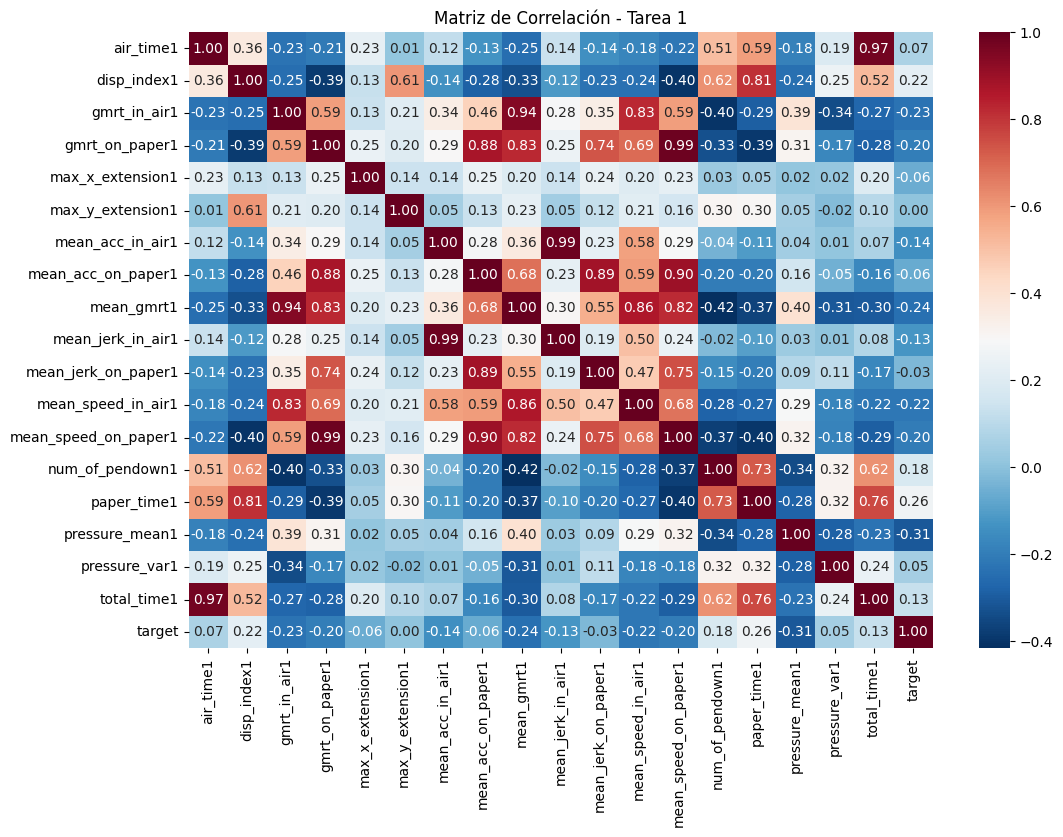

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



🔹 Variables que más influyen en el diagnóstico (Regresión):
                      Coeficiente   P-valor
paper_time1              6.349095  1.000000
mean_jerk_in_air1        2.240266  0.505271
gmrt_on_paper1           1.919640       NaN
gmrt_in_air1             1.591274       NaN
total_time1              0.972963  1.000000
mean_jerk_on_paper1      0.679724  0.194887
max_y_extension1         0.262991  0.485669
num_of_pendown1         -0.128254  0.779618
mean_speed_in_air1      -0.210173  0.690473
max_x_extension1        -0.211257  0.538746
mean_speed_on_paper1    -0.324096  0.845839
mean_acc_on_paper1      -0.491356  0.596826
pressure_var1           -0.621144  0.045195
pressure_mean1          -0.693954  0.011863
air_time1               -1.040032  1.000000
mean_acc_in_air1        -2.416079  0.484636
mean_gmrt1              -2.574753       NaN
disp_index1             -2.734132  0.035214


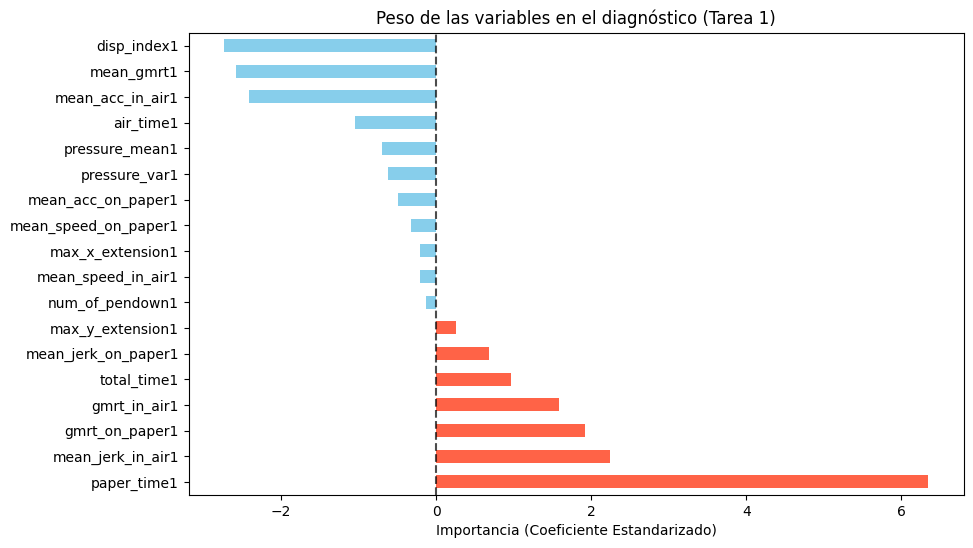

In [8]:
def analizar_tarea2(df, num_tarea):
    """
    Realiza un análisis integral de una tarea: filtrado, outliers, 
    correlación y regresión de influencia.
    """
    suffix = str(num_tarea)
    
    # 1. FILTRADO DE COLUMNAS
    cols_tarea = []
    for col in df.columns:
        if col.endswith(suffix):
            posible_prefijo = col[:-(len(suffix))]
            if not posible_prefijo[-1:].isdigit():
                cols_tarea.append(col)

    if not cols_tarea:
        print(f"⚠️ No se encontraron columnas para la tarea {num_tarea}")
        return

    # Crear subset de trabajo
    df_tarea = df[cols_tarea + ['class']].copy()
    # Mapeo numérico para cálculos: P (Paciente) = 1, H (Sano) = 0
    df_tarea['target'] = df_tarea['class'].map({'P': 1, 'H': 0})
    
    print(f"\n{'='*40}")
    print(f"📊 INFORME INTEGRAL: TAREA {num_tarea}")
    print(f"{'='*40}")

    # 2. DETECCIÓN DE OUTLIERS (Método IQR)
    # Se define como valores fuera de: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    outliers_resumen = {}
    for col in cols_tarea:
        Q1 = df_tarea[col].quantile(0.25)
        Q3 = df_tarea[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        n_outliers = df_tarea[(df_tarea[col] < limite_inf) | (df_tarea[col] > limite_sup)].shape[0]
        outliers_resumen[col] = n_outliers
    
    print("\n🔹 Conteo de Outliers por variable:")
    print(pd.Series(outliers_resumen))

    # 3. MAPA DE CORRELACIÓN
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_tarea.drop('class', axis=1).corr(), annot=True, cmap='RdBu_r', fmt=".2f")
    plt.title(f'Matriz de Correlación - Tarea {num_tarea}')
    plt.show()

    # 4. REGRESIÓN E INFLUENCIA (Logística)
    # Preparamos X (estandarizada) y y
    X = df_tarea[cols_tarea]
    y = df_tarea['target']
    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X_scaled = sm.add_constant(X_scaled) # Añadir intercepto

    try:
        modelo = sm.Logit(y, X_scaled).fit(disp=0)
        
        # Extraer coeficientes para ver influencia
        influencia = pd.DataFrame({
            'Coeficiente': modelo.params.drop('const'),
            'P-valor': modelo.pvalues.drop('const')
        }).sort_values(by='Coeficiente', ascending=False)

        print("\n🔹 Variables que más influyen en el diagnóstico (Regresión):")
        print(influencia)

        # Gráfico de Influencia
        plt.figure(figsize=(10, 6))
        colores = ['tomato' if c > 0 else 'skyblue' for c in influencia['Coeficiente']]
        influencia['Coeficiente'].plot(kind='barh', color=colores)
        plt.axvline(0, color='black', linestyle='--', alpha=0.7)
        plt.title(f'Peso de las variables en el diagnóstico (Tarea {num_tarea})')
        plt.xlabel('Importancia (Coeficiente Estandarizado)')
        plt.show()
        
    except Exception as e:
        print(f"\n⚠️ No se pudo completar la regresión: {e}")
        print("Esto sucede a veces si las variables están demasiado correlacionadas (multicolinealidad).")

# Uso:
analizar_tarea2(df, 1)